In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # this notebook lives in notebooks/
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

assert OUTPUTS_DIR.exists(), f"Expected outputs directory not found at {OUTPUTS_DIR}"
print("Reading existing outputs from:", OUTPUTS_DIR)

Reading existing outputs from: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs


## Load Existing Outputs

Every file below already exists in `outputs/`. Nothing is recomputed from raw events.

In [2]:
segments_path       = OUTPUTS_DIR / "segments.jsonl"
summary_path        = OUTPUTS_DIR / "segmentation_summary.csv"
session_summary_path= OUTPUTS_DIR / "session_summary.csv"
process_summary_path= OUTPUTS_DIR / "process_summary.csv"
quality_report_path = OUTPUTS_DIR / "segmentation_quality_report.json"
features_path        = OUTPUTS_DIR / "process_automation_features.csv"
ranking_path         = OUTPUTS_DIR / "process_automation_ranking.csv"
methodology_path     = OUTPUTS_DIR / "process_automation_methodology.json"

segments              = pd.DataFrame([json.loads(l) for l in open(segments_path, encoding="utf-8") if l.strip()])
segmentation_summary  = pd.read_csv(summary_path)
session_summary       = pd.read_csv(session_summary_path)
process_summary       = pd.read_csv(process_summary_path)
process_features      = pd.read_csv(features_path)
process_ranking        = pd.read_csv(ranking_path)

with open(quality_report_path, encoding="utf-8") as f:
    quality_report = json.load(f)
with open(methodology_path, encoding="utf-8") as f:
    methodology = json.load(f)

segmentation_summary["pred_start"] = pd.to_datetime(segmentation_summary["pred_start"], format="mixed", utc=True)
segmentation_summary["pred_end"]   = pd.to_datetime(segmentation_summary["pred_end"], format="mixed", utc=True)
segments["start"] = pd.to_datetime(segments["start"], utc=True)
segments["end"]   = pd.to_datetime(segments["end"], utc=True)

print("segments.jsonl                     :", segments.shape)
print("segmentation_summary.csv           :", segmentation_summary.shape)
print("session_summary.csv                :", session_summary.shape)
print("process_summary.csv                :", process_summary.shape)
print("process_automation_features.csv    :", process_features.shape)
print("process_automation_ranking.csv     :", process_ranking.shape)

segments.jsonl                     : (98, 4)
segmentation_summary.csv           : (98, 26)
session_summary.csv                : (15, 8)
process_summary.csv                : (5, 7)
process_automation_features.csv    : (5, 14)
process_automation_ranking.csv     : (3, 18)


## Validate Data

Sanity checks before this notebook's evidence is built on top of these files.

In [3]:
issues = []

# Row-count / label-set consistency across the Step-1 files
if len(segments) != len(segmentation_summary):
    issues.append(f"segments.jsonl has {len(segments)} rows vs segmentation_summary.csv {len(segmentation_summary)}")
if set(segments["label"]) != set(segmentation_summary["label"]):
    issues.append("Label sets differ between segments.jsonl and segmentation_summary.csv")

# The selection-stage outputs should be a subset of labels seen in segmentation_summary
if not set(process_ranking["label"]).issubset(set(segmentation_summary["label"])):
    issues.append("process_automation_ranking.csv contains labels not present in segmentation_summary.csv")

# Missing values in the columns this notebook depends on
required_cols = ["label", "pred_duration_s", "n_events", "n_distinct_apps", "dominant_app_grouped",
                  "has_any_extracted_text", "n_extracted_text_events"] + \
                [c for c in segmentation_summary.columns if c.startswith("frac_")]
na_counts = segmentation_summary[required_cols].isna().sum()
na_counts = na_counts[na_counts > 0]
if len(na_counts):
    issues.append(f"Missing values in required columns:\n{na_counts}")

# Duplicate segment records
dupes = segmentation_summary.duplicated(subset=["session_id", "pred_start", "pred_end"]).sum()
if dupes:
    issues.append(f"{dupes} duplicate (session_id, pred_start, pred_end) rows")

# Timestamp ordering
bad_order = (segmentation_summary["pred_start"] >= segmentation_summary["pred_end"]).sum()
if bad_order:
    issues.append(f"{bad_order} segments with start >= end")

# Known upstream issue -- surfaced, not silently ignored
merge_floor_flag = quality_report.get("no_segments_below_merge_floor", {})
if merge_floor_flag.get("passed") is False:
    print(f"[KNOWN ISSUE -- carried over from segmentation_quality_report.json] {merge_floor_flag.get('detail')}")
    print("This notebook proceeds using the segmentation as delivered; see Section 'Limitations' below.\n")

if issues:
    print("[DATA ISSUES FOUND]")
    for i in issues:
        print(" -", i)
else:
    print("[OK] segments.jsonl, segmentation_summary.csv and the process_automation_* outputs "
          "agree on schema, row counts, and label sets. No missing values in required columns, "
          "no duplicate segments, no timestamp ordering errors.")

[KNOWN ISSUE -- carried over from segmentation_quality_report.json] 9 segment(s) shorter than the 15s merge floor (should be structurally impossible given the merge step; a non-zero count needs investigation)
This notebook proceeds using the segmentation as delivered; see Section 'Limitations' below.

[OK] segments.jsonl, segmentation_summary.csv and the process_automation_* outputs agree on schema, row counts, and label sets. No missing values in required columns, no duplicate segments, no timestamp ordering errors.


## Identify the Selected Process

Retrieved programmatically from `process_automation_ranking.csv` (rank 1) and cross-checked against `process_automation_methodology.json`'s recorded `top_candidate` -- the process name is never hardcoded.

In [4]:
assert process_ranking["rank"].min() == 1, "process_automation_ranking.csv is not rank-ordered as expected"

top_row = process_ranking.loc[process_ranking["rank"] == 1].iloc[0]
SELECTED_PROCESS = top_row["label"]

assert SELECTED_PROCESS == methodology["top_candidate"], (
    "Mismatch between process_automation_ranking.csv rank-1 label and "
    "process_automation_methodology.json's recorded top_candidate -- selection stage outputs "
    "are inconsistent and should be re-checked before trusting this notebook's evidence."
)

print(f"SELECTED PROCESS (from rank 1 of process_automation_ranking.csv): {SELECTED_PROCESS}")
print(f"Recommendation tier recorded at selection time: {top_row['recommendation']}")
print(f"Automation score recorded at selection time    : {top_row['automation_score']:.4f}")
print(f"Cross-check win-share under 5,000 random weight draws "
      f"(process_automation_methodology.json): "
      f"{methodology['weight_sensitivity_win_share_pct'].get(SELECTED_PROCESS, 'n/a')}%")

SELECTED PROCESS (from rank 1 of process_automation_ranking.csv): process_cluster_0
Recommendation tier recorded at selection time: Strong candidate
Automation score recorded at selection time    : 0.9286
Cross-check win-share under 5,000 random weight draws (process_automation_methodology.json): 100.0%


## Selected Process Profile

All figures below are computed directly from `segmentation_summary.csv` / `segments.jsonl`, filtered to `SELECTED_PROCESS` -- not read back from `process_automation_features.csv` -- so this notebook independently reproduces (and thereby double-checks) the numbers the selection stage relied on.

In [5]:
def parse_machine_id(session_id: str) -> str:
    # Same logic used in segmentation_datasetb.ipynb / process_automation_selection.ipynb,
    # reused here for consistency rather than re-derived.
    parts = session_id.split("-", 2)
    return parts[2] if len(parts) == 3 else "unknown"

sel = segmentation_summary[segmentation_summary["label"] == SELECTED_PROCESS].copy()
sel["machine"] = sel["session_id"].apply(parse_machine_id)

n_sessions_total = session_summary["session_id"].nunique()
grand_total_duration_s = segmentation_summary["pred_duration_s"].sum()

profile = {
    "process_segment": SELECTED_PROCESS,
    "n_occurrences": len(sel),
    "n_sessions_present": sel["session_id"].nunique(),
    "n_sessions_total_dataset_b": n_sessions_total,
    "session_coverage_pct": round(sel["session_id"].nunique() / n_sessions_total * 100, 1),
    "n_distinct_machines": sel["machine"].nunique(),
    "total_duration_s": round(sel["pred_duration_s"].sum(), 1),
    "pct_of_total_observed_time": round(sel["pred_duration_s"].sum() / grand_total_duration_s * 100, 1),
    "mean_duration_s": round(sel["pred_duration_s"].mean(), 1),
    "median_duration_s": round(sel["pred_duration_s"].median(), 1),
    "std_duration_s": round(sel["pred_duration_s"].std(), 1),
    "min_duration_s": round(sel["pred_duration_s"].min(), 1),
    "max_duration_s": round(sel["pred_duration_s"].max(), 1),
    "mean_n_events": round(sel["n_events"].mean(), 1),
    "median_n_events": round(sel["n_events"].median(), 1),
    "mean_n_distinct_apps": round(sel["n_distinct_apps"].mean(), 2),
    "dominant_apps": sel["dominant_app_grouped"].value_counts().to_dict(),
    "pct_segments_with_extracted_text": round(sel["has_any_extracted_text"].mean() * 100, 1),
    "mean_n_extracted_text_events": round(sel["n_extracted_text_events"].mean(), 1),
}

profile_df = pd.DataFrame([profile])
print(f"Profile of {SELECTED_PROCESS}:\n")
for k, v in profile.items():
    print(f"  {k:35s}: {v}")

Profile of process_cluster_0:

  process_segment                    : process_cluster_0
  n_occurrences                      : 64
  n_sessions_present                 : 14
  n_sessions_total_dataset_b         : 15
  session_coverage_pct               : 93.3
  n_distinct_machines                : 4
  total_duration_s                   : 5446.2
  pct_of_total_observed_time         : 51.5
  mean_duration_s                    : 85.1
  median_duration_s                  : 73.0
  std_duration_s                     : 41.5
  min_duration_s                     : 37.0
  max_duration_s                     : 176.9
  mean_n_events                      : 159.5
  median_n_events                    : 135.5
  mean_n_distinct_apps               : 2.66
  dominant_apps                      : {'Microsoft Edge': 60, 'Microsoft Word': 4}
  pct_segments_with_extracted_text   : 100.0
  mean_n_extracted_text_events       : 7.2


## Evidence Analysis

Each subsection below answers one specific automation-suitability question and states
its conclusion as **Observed from data**, **Inference**, or **Not established by the data**
(see the closing note in each subsection). Nothing here restates the raw metric as a
qualitative label without showing the metric first.

### 1. Repetition

In [6]:
occ_by_label = segmentation_summary["label"].value_counts().sort_values(ascending=False)
sessions_by_label = segmentation_summary.groupby("label")["session_id"].nunique().reindex(occ_by_label.index)

print("Occurrences per process segment (all labels in Dataset B):")
print(pd.DataFrame({"n_occurrences": occ_by_label, "n_sessions": sessions_by_label}))
print()
print(f"OBSERVED: {SELECTED_PROCESS} occurs {profile['n_occurrences']} times, "
      f"the highest occurrence count of any process segment in Dataset B, "
      f"and appears in {profile['n_sessions_present']}/{profile['n_sessions_total_dataset_b']} "
      f"sessions ({profile['session_coverage_pct']}% session coverage) across "
      f"{profile['n_distinct_machines']} distinct machines.")
print("INFERENCE: a procedure that recurs this often, across most sessions and multiple "
      "operators/machines, is a standing routine rather than a one-off task -- each unit of "
      "automation-build effort here is amortized over more repetitions than for any other "
      "candidate segment.")

Occurrences per process segment (all labels in Dataset B):
                   n_occurrences  n_sessions
label                                       
process_cluster_0             64          14
process_cluster_4             18          12
process_cluster_1             13          10
process_cluster_3              2           1
process_cluster_2              1           1

OBSERVED: process_cluster_0 occurs 64 times, the highest occurrence count of any process segment in Dataset B, and appears in 14/15 sessions (93.3% session coverage) across 4 distinct machines.
INFERENCE: a procedure that recurs this often, across most sessions and multiple operators/machines, is a standing routine rather than a one-off task -- each unit of automation-build effort here is amortized over more repetitions than for any other candidate segment.


### 2. Time / Effort Opportunity

In [7]:
time_by_label = (
    segmentation_summary.groupby("label")["pred_duration_s"]
    .agg(total_duration_s="sum", mean_duration_s="mean", median_duration_s="median")
    .assign(pct_of_total_time=lambda d: d["total_duration_s"] / grand_total_duration_s * 100)
    .sort_values("total_duration_s", ascending=False)
)
print(time_by_label.round(1))
print()
print(f"OBSERVED: {SELECTED_PROCESS} accounts for {profile['total_duration_s']}s of total "
      f"logged activity time across Dataset B -- {profile['pct_of_total_observed_time']}% of "
      f"all observed session time ({grand_total_duration_s:.0f}s total, per "
      f"session_summary.csv / segmentation_summary.csv). Median execution length is "
      f"{profile['median_duration_s']}s (mean {profile['mean_duration_s']}s).")
print("INFERENCE: this is the single largest block of recurring,同一 (same-procedure) human "
      "time visible in the dataset -- automating it addresses the largest available share of "
      "repetitive work, not a marginal one. The recording environment is a test environment "
      "with shortened wait times (per DATA_SCHEMA.md / README.md), so these are relative, not "
      "production-scale, time figures.")
print("NOT ESTABLISHED BY THE DATA: what fraction of this time an automation could actually "
      "remove (vs. time that would still require human review/exception handling) -- see "
      "'Human Interaction' below.")

                   total_duration_s  mean_duration_s  median_duration_s  pct_of_total_time
label                                                                                     
process_cluster_0            5446.2             85.1               73.0               51.5
process_cluster_4            4622.4            256.8              236.8               43.7
process_cluster_1             248.4             19.1               13.4                2.3
process_cluster_3             241.5            120.8              120.8                2.3
process_cluster_2              16.3             16.3               16.3                0.2

OBSERVED: process_cluster_0 accounts for 5446.2s of total logged activity time across Dataset B -- 51.5% of all observed session time (10575s total, per session_summary.csv / segmentation_summary.csv). Median execution length is 73.0s (mean 85.1s).
INFERENCE: this is the single largest block of recurring,同一 (same-procedure) human time visible in the dataset --

### 3. Consistency (event-type mix across executions)

Behavioral consistency (avg std across event-type-mix fractions; lower = more stereotyped):
            label  n_occurrences  behavioral_cv
process_cluster_0             64         0.0204
process_cluster_3              2         0.0211
process_cluster_4             18         0.0273
process_cluster_1             13         0.0279
process_cluster_2              1            NaN


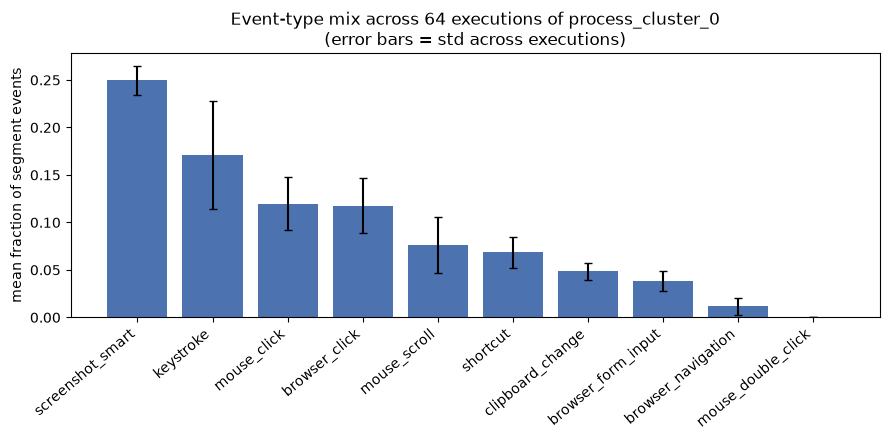


OBSERVED: process_cluster_0 has a behavioral_cv of 0.0204, the lowest of all 5 process segments in Dataset B -- the error bars above are small relative to the mean fractions, i.e. the mix of keystrokes/clicks/navigation/screenshots is similar from one execution to the next.
INFERENCE: low variance in *how* the process is carried out (independent of how long it takes) is evidence of a standardized procedure rather than ad-hoc, judgment-heavy work.


In [8]:
FRAC_COLS = [c for c in segmentation_summary.columns if c.startswith("frac_")]

consistency_rows = []
for label, g in segmentation_summary.groupby("label"):
    n = len(g)
    consistency_rows.append({
        "label": label,
        "n_occurrences": n,
        "behavioral_cv": g[FRAC_COLS].std().mean() if n > 1 else np.nan,  # same definition as process_automation_selection.ipynb
    })
consistency_df = pd.DataFrame(consistency_rows).sort_values("behavioral_cv")
print("Behavioral consistency (avg std across event-type-mix fractions; lower = more stereotyped):")
print(consistency_df.round(4).to_string(index=False))

sel_frac_mean = sel[FRAC_COLS].mean().sort_values(ascending=False)
sel_frac_std  = sel[FRAC_COLS].std().reindex(sel_frac_mean.index)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(sel_frac_mean))
ax.bar(x, sel_frac_mean.values, yerr=sel_frac_std.values, capsize=3, color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("frac_", "") for c in sel_frac_mean.index], rotation=40, ha="right")
ax.set_ylabel("mean fraction of segment events")
ax.set_title(f"Event-type mix across {profile['n_occurrences']} executions of {SELECTED_PROCESS}\n(error bars = std across executions)")
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "process_automation_justification_consistency.png", dpi=150, bbox_inches="tight")
plt.show()

sel_behavioral_cv = consistency_df.loc[consistency_df["label"] == SELECTED_PROCESS, "behavioral_cv"].iloc[0]
rank_among_all = int((consistency_df["behavioral_cv"] < sel_behavioral_cv).sum() + 1)
print(f"\nOBSERVED: {SELECTED_PROCESS} has a behavioral_cv of {sel_behavioral_cv:.4f}, the "
      f"{'lowest' if rank_among_all == 1 else f'{rank_among_all}-lowest'} of all "
      f"{len(consistency_df)} process segments in Dataset B -- the error bars above are small "
      "relative to the mean fractions, i.e. the mix of keystrokes/clicks/navigation/screenshots "
      "is similar from one execution to the next.")
print("INFERENCE: low variance in *how* the process is carried out (independent of how long it "
      "takes) is evidence of a standardized procedure rather than ad-hoc, judgment-heavy work.")

### 4. Variability (execution duration)

                    n     mean   median      std     cv
label                                                  
process_cluster_3   2  120.760  120.760   53.154  0.440
process_cluster_0  64   85.096   72.996   41.466  0.487
process_cluster_4  18  256.800  236.770  129.596  0.505
process_cluster_1  13   19.111   13.367   18.065  0.945
process_cluster_2   1   16.281   16.281      NaN    NaN


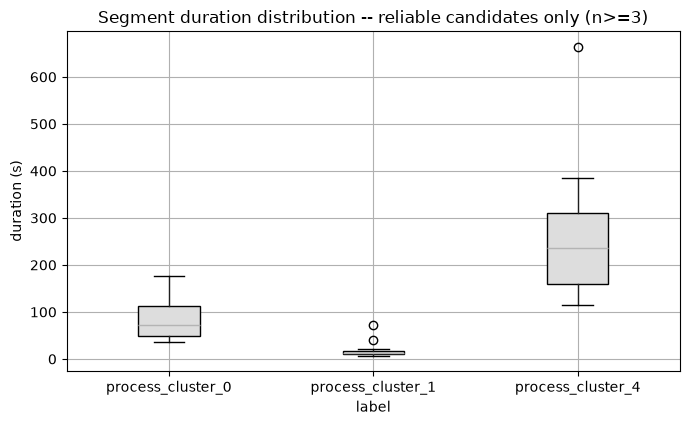


OBSERVED: process_cluster_0 has duration_cv = 0.487 (std 41.5s / mean 85.1s). This is moderate, not low -- execution length varies noticeably even though the *behavior mix* (previous section) does not.
INFERENCE: this pattern (stable behavior mix, variable duration) is more consistent with the same fixed procedure being applied to a variable number of records/cases per execution, than with different procedures being followed each time -- but that interpretation should be confirmed against domain knowledge of the underlying business process, not assumed from the event log alone.


In [9]:
dur_stats = (
    segmentation_summary.groupby("label")["pred_duration_s"]
    .agg(n="count", mean="mean", median="median", std="std")
    .assign(cv=lambda d: d["std"] / d["mean"])
    .sort_values("cv")
)
print(dur_stats.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
reliable_labels = process_ranking["label"].tolist()  # labels that passed the n>=3 reliability floor upstream
plot_df = segmentation_summary[segmentation_summary["label"].isin(reliable_labels)]
colors = ["#C44E52" if lbl == SELECTED_PROCESS else "#8C8C8C" for lbl in sorted(plot_df["label"].unique())]
plot_df.boxplot(column="pred_duration_s", by="label", ax=ax,
                 patch_artist=True,
                 boxprops=dict(facecolor="#DDDDDD"))
ax.set_title(f"Segment duration distribution -- reliable candidates only (n>={methodology['min_occurrences_for_ranking']})")
plt.suptitle("")
ax.set_ylabel("duration (s)")
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "process_automation_justification_duration_variability.png", dpi=150, bbox_inches="tight")
plt.show()

sel_cv = dur_stats.loc[SELECTED_PROCESS, "cv"]
print(f"\nOBSERVED: {SELECTED_PROCESS} has duration_cv = {sel_cv:.3f} (std {dur_stats.loc[SELECTED_PROCESS,'std']:.1f}s "
      f"/ mean {dur_stats.loc[SELECTED_PROCESS,'mean']:.1f}s). This is moderate, not low -- "
      "execution length varies noticeably even though the *behavior mix* (previous section) does not.")
print("INFERENCE: this pattern (stable behavior mix, variable duration) is more consistent with "
      "the same fixed procedure being applied to a variable number of records/cases per "
      "execution, than with different procedures being followed each time -- but that "
      "interpretation should be confirmed against domain knowledge of the underlying business "
      "process, not assumed from the event log alone.")

### 5. Complexity (steps per execution)

                   mean_n_events  median_n_events  std_n_events  mean_n_distinct_apps  n_unique_dominant_apps
label                                                                                                        
process_cluster_1          22.54             18.0         14.10                  3.54                       2
process_cluster_2          24.00             24.0           NaN                  3.00                       1
process_cluster_0         159.48            135.5         75.01                  2.66                       2
process_cluster_3         406.00            406.0          9.90                  4.50                       2
process_cluster_4         507.83            468.0        232.45                  4.22                       3


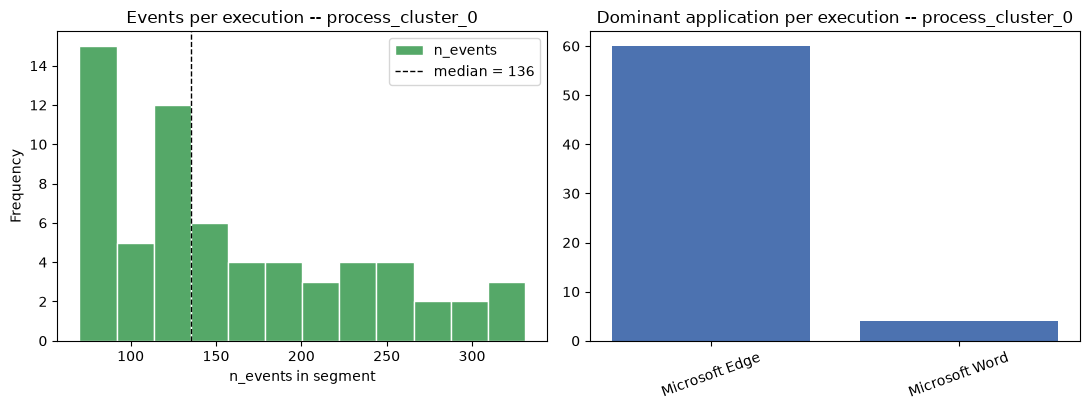


OBSERVED: executions of process_cluster_0 involve a median of 136 raw events (mean 159.5), touching a mean of 2.66 distinct applications, with 2 distinct dominant application(s) observed: {'Microsoft Edge': 60, 'Microsoft Word': 4}.
INFERENCE: a bounded, small number of applications and a moderate event count per execution keeps the integration surface for an automation tool small relative to candidates that touch more applications per execution (see Comparison section).
NOT ESTABLISHED BY THE DATA: how many of these events represent required decision points vs. mechanical steps -- event *count* is a complexity proxy, not a measure of how many branches/decisions the procedure has.


In [10]:
complexity_stats = (
    segmentation_summary.groupby("label")
    .agg(mean_n_events=("n_events", "mean"),
         median_n_events=("n_events", "median"),
         std_n_events=("n_events", "std"),
         mean_n_distinct_apps=("n_distinct_apps", "mean"),
         n_unique_dominant_apps=("dominant_app_grouped", "nunique"))
    .sort_values("mean_n_events")
)
print(complexity_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sel["n_events"].plot(kind="hist", bins=12, ax=axes[0], color="#55A868", edgecolor="white")
axes[0].axvline(sel["n_events"].median(), color="black", linestyle="--", linewidth=1,
                label=f"median = {sel['n_events'].median():.0f}")
axes[0].set_title(f"Events per execution -- {SELECTED_PROCESS}")
axes[0].set_xlabel("n_events in segment")
axes[0].legend()

app_counts = sel["dominant_app_grouped"].value_counts()
axes[1].bar(app_counts.index, app_counts.values, color="#4C72B0")
axes[1].set_title(f"Dominant application per execution -- {SELECTED_PROCESS}")
axes[1].tick_params(axis="x", labelrotation=20)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "process_automation_justification_complexity_apps.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOBSERVED: executions of {SELECTED_PROCESS} involve a median of "
      f"{sel['n_events'].median():.0f} raw events (mean {sel['n_events'].mean():.1f}), touching "
      f"a mean of {sel['n_distinct_apps'].mean():.2f} distinct applications, with "
      f"{len(app_counts)} distinct dominant application(s) observed: {app_counts.to_dict()}.")
print("INFERENCE: a bounded, small number of applications and a moderate event count per "
      "execution keeps the integration surface for an automation tool small relative to "
      "candidates that touch more applications per execution (see Comparison section).")
print("NOT ESTABLISHED BY THE DATA: how many of these events represent required decision "
      "points vs. mechanical steps -- event *count* is a complexity proxy, not a measure of "
      "how many branches/decisions the procedure has.")

### 6. Application Interaction Pattern

In [11]:
structured_cols = ["frac_browser_form_input", "frac_browser_click", "frac_browser_navigation"]
sel_structured_share = sel[structured_cols].sum(axis=1)

print("Structured (browser/DOM) interaction share per execution -- summary:")
print(sel_structured_share.describe().round(3))
print()
print("Text-extraction coverage (context.extracted_text availability, per segmentation_summary.csv):")
print(f"  segments with any extracted text : {profile['pct_segments_with_extracted_text']}%")
print(f"  mean n_extracted_text_events     : {profile['mean_n_extracted_text_events']}")
print()
print(f"OBSERVED: {(sel['dominant_app_grouped']=='Microsoft Edge').mean()*100:.0f}% of "
      f"{SELECTED_PROCESS} executions are dominated by a single application (Microsoft Edge), "
      f"with a mean structured-interaction share of {sel_structured_share.mean():.3f} "
      "(browser form-fill/click/navigation events as a fraction of all events in the segment). "
      f"{profile['pct_segments_with_extracted_text']}% of executions have at least one "
      "on-screen text extraction available.")
print("INFERENCE: repeated interaction with the same browser-based system, combined with a "
      "non-trivial structured-interaction share, suggests this process is more addressable via "
      "web-based automation (DOM automation / API integration if one exists) than via fragile "
      "screen-coordinate RPA -- though the majority of events are still raw keystroke/mouse "
      "activity, not structured browser events (see the event-type mix in the Consistency plot).")

Structured (browser/DOM) interaction share per execution -- summary:
count    64.000
mean      0.168
std       0.038
min       0.091
25%       0.136
50%       0.164
75%       0.189
max       0.250
dtype: float64

Text-extraction coverage (context.extracted_text availability, per segmentation_summary.csv):
  segments with any extracted text : 100.0%
  mean n_extracted_text_events     : 7.2

OBSERVED: 94% of process_cluster_0 executions are dominated by a single application (Microsoft Edge), with a mean structured-interaction share of 0.168 (browser form-fill/click/navigation events as a fraction of all events in the segment). 100.0% of executions have at least one on-screen text extraction available.
INFERENCE: repeated interaction with the same browser-based system, combined with a non-trivial structured-interaction share, suggests this process is more addressable via web-based automation (DOM automation / API integration if one exists) than via fragile screen-coordinate RPA -- though 

### 7. Human Interaction / Decision-Making

**Not established by the data.** The current outputs contain no field indicating whether a
human is making a business decision, exercising judgment, or simply executing a fixed
sequence of steps during a segment. `process_automation_methodology.json` records this
explicitly under `factors_not_available_in_current_outputs`:

In [12]:
for factor in methodology["factors_not_available_in_current_outputs"]:
    print(" -", factor)

print()
print("This notebook does not claim, and the data does not support claiming, that "
      f"{SELECTED_PROCESS} 'requires no human judgment' or is 'fully deterministic'. What can "
      "be said, and only this, is:")
print(f"  - keystroke/mouse/click events dominate the event-type mix (see Consistency section) "
      "-- consistent with manual data entry and navigation, but this does not by itself rule "
      "out judgment calls embedded in *which* values are entered or *which* navigation path is "
      "taken.")
print("  - No error/interruption event types (browser_error, browser_alert, dialog_opened) are "
      "counted in the current per-segment features, so their frequency during this process "
      "cannot be assessed from these outputs.")
print("A reliable answer would require either domain-expert review of a sample of raw sessions/"
      "screenshots for this cluster, or extending the Step-1 feature extraction to flag "
      "decision-relevant signals -- both out of scope for this notebook, which only consumes "
      "existing outputs.")

 - human_decision_making_presence
 - error_or_interruption_rate
 - exact_distance_to_cluster_centroid

This notebook does not claim, and the data does not support claiming, that process_cluster_0 'requires no human judgment' or is 'fully deterministic'. What can be said, and only this, is:
  - keystroke/mouse/click events dominate the event-type mix (see Consistency section) -- consistent with manual data entry and navigation, but this does not by itself rule out judgment calls embedded in *which* values are entered or *which* navigation path is taken.
  - No error/interruption event types (browser_error, browser_alert, dialog_opened) are counted in the current per-segment features, so their frequency during this process cannot be assessed from these outputs.
A reliable answer would require either domain-expert review of a sample of raw sessions/screenshots for this cluster, or extending the Step-1 feature extraction to flag decision-relevant signals -- both out of scope for this noteb

## Comparison with Alternative Candidates

Only candidates that passed the selection stage's statistical reliability floor
(`n_occurrences >= 3`, i.e. `process_automation_ranking.csv`) are compared here.
`process_cluster_2` and `process_cluster_3` are excluded for the same reason they were excluded
upstream: too few occurrences (1 and 2 respectively) to characterize reliably, not because they
were unfavorable on any metric.

In [13]:
comparison_cols = ["rank", "label", "n_occurrences", "n_sessions", "pct_of_total_observed_time",
                    "median_duration_s", "duration_cv", "mean_n_events", "mean_n_distinct_apps",
                    "structured_interaction_share", "behavioral_cv", "automation_score", "recommendation"]
comparison = process_ranking[comparison_cols].sort_values("rank").reset_index(drop=True)
comparison_display = comparison.round(3)
print(comparison_display.to_string(index=False))

print(f"\nExcluded as statistically unreliable (n_occurrences < {methodology['min_occurrences_for_ranking']}): "
      f"{methodology['excluded_labels']}")

 rank             label  n_occurrences  n_sessions  pct_of_total_observed_time  median_duration_s  duration_cv  mean_n_events  mean_n_distinct_apps  structured_interaction_share  behavioral_cv  automation_score   recommendation
    1 process_cluster_0             64          14                      51.501             72.996        0.487        159.484                 2.656                         0.168          0.020             0.929 Strong candidate
    2 process_cluster_4             18          12                      43.711            236.770        0.505        507.833                 4.222                         0.111          0.027             0.354     Low priority
    3 process_cluster_1             13          10                       2.349             13.367        0.945         22.538                 3.538                         0.166          0.028             0.271     Low priority

Excluded as statistically unreliable (n_occurrences < 3): ['process_cluster_2', 'proces

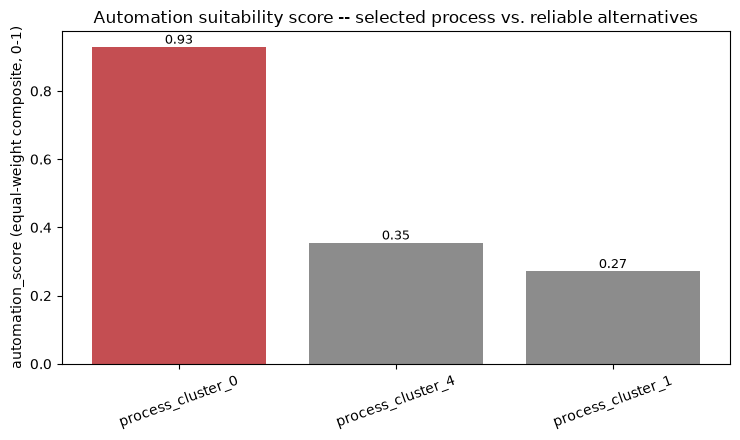

OBSERVED: the runner-up, process_cluster_4, has a comparable time footprint (43.7% of total observed time vs. 51.5% for process_cluster_0), but a higher mean event count per execution (507.8 vs. 159.5) and touches more distinct applications per execution (4.22 vs. 2.66).
INFERENCE: the runner-up is a larger, more complex automation target with a correspondingly higher expected build cost and integration surface, for a similar time-savings ceiling -- this is why it ranks below the selected process rather than above it.

Robustness check (from process_automation_methodology.json): across 5000 random re-weightings of the same seven scoring features, process_cluster_0 wins 100.0% of the time -- the ranking is not an artifact of the specific (equal) weighting chosen upstream.


In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = ["#C44E52" if lbl == SELECTED_PROCESS else "#8C8C8C" for lbl in comparison["label"]]
bars = ax.bar(comparison["label"], comparison["automation_score"], color=colors)
ax.set_ylabel("automation_score (equal-weight composite, 0-1)")
ax.set_title("Automation suitability score -- selected process vs. reliable alternatives")
ax.tick_params(axis="x", labelrotation=20)
for b, v in zip(bars, comparison["automation_score"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "process_automation_justification_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

runner_up = comparison.iloc[1] if len(comparison) > 1 else None
if runner_up is not None:
    print(f"OBSERVED: the runner-up, {runner_up['label']}, has a comparable time footprint "
          f"({runner_up['pct_of_total_observed_time']:.1f}% of total observed time vs. "
          f"{comparison.iloc[0]['pct_of_total_observed_time']:.1f}% for {SELECTED_PROCESS}), "
          f"but a higher mean event count per execution ({runner_up['mean_n_events']:.1f} vs. "
          f"{comparison.iloc[0]['mean_n_events']:.1f}) and touches more distinct applications "
          f"per execution ({runner_up['mean_n_distinct_apps']:.2f} vs. "
          f"{comparison.iloc[0]['mean_n_distinct_apps']:.2f}).")
    print("INFERENCE: the runner-up is a larger, more complex automation target with a "
          "correspondingly higher expected build cost and integration surface, for a similar "
          "time-savings ceiling -- this is why it ranks below the selected process rather than "
          "above it.")

print(f"\nRobustness check (from process_automation_methodology.json): across "
      f"{methodology['weight_sensitivity_n_trials']} random re-weightings of the same seven "
      f"scoring features, {SELECTED_PROCESS} wins "
      f"{methodology['weight_sensitivity_win_share_pct'].get(SELECTED_PROCESS, 'n/a')}% of the "
      "time -- the ranking is not an artifact of the specific (equal) weighting chosen upstream.")

## Final Automation Justification

In [15]:
justification_text = f'''
SELECTED PROCESS
----------------
{SELECTED_PROCESS}

AUTOMATION JUSTIFICATION
------------------------
Repetition:
  {profile['n_occurrences']} occurrences across {profile['n_sessions_present']}/{profile['n_sessions_total_dataset_b']}
  sessions ({profile['session_coverage_pct']}% coverage), {profile['n_distinct_machines']} distinct
  machines -- the most frequent process segment in Dataset B.

Time Opportunity:
  {profile['total_duration_s']}s total observed time ({profile['pct_of_total_observed_time']}% of all
  logged Dataset B activity time), median execution {profile['median_duration_s']}s.

Consistency (event-type mix):
  behavioral_cv = {sel_behavioral_cv:.4f}, the {'lowest' if rank_among_all == 1 else f'{rank_among_all}-lowest'}
  among all {len(consistency_df)} segments -- executions follow a similar mix of actions.

Variability (duration):
  duration_cv = {sel_cv:.3f} -- moderate; execution length varies more than the action mix does.

Complexity:
  median {sel['n_events'].median():.0f} events/execution, mean {sel['n_distinct_apps'].mean():.2f}
  distinct applications, dominant apps observed: {app_counts.to_dict()}.

Application interaction:
  mean structured (browser form/click/navigation) interaction share = {sel_structured_share.mean():.3f};
  {(sel['dominant_app_grouped']=='Microsoft Edge').mean()*100:.0f}% of executions dominated by a single
  browser-based application.

Human interaction / decision-making:
  Not established by the available data -- no field indicates presence/absence of judgment calls
  or error/interruption events for this process. See Section 7.

Comparison with alternatives:
  automation_score {comparison.iloc[0]['automation_score']:.3f} vs. runner-up
  {runner_up['label'] if runner_up is not None else 'n/a'} at
  {(f"{runner_up['automation_score']:.3f}" if runner_up is not None else 'n/a')} -- robust to
  weighting choice ({methodology['weight_sensitivity_win_share_pct'].get(SELECTED_PROCESS, 'n/a')}%
  win-share across {methodology['weight_sensitivity_n_trials']} random re-weightings).

FINAL ASSESSMENT
----------------
{SELECTED_PROCESS} is the most frequent, highest-time-footprint, and most behaviorally
consistent reliable process segment identified in Dataset B, with a moderate-but-bounded
duration spread and a small, browser-centric application footprint. This is evidence-based
support for prioritizing it as the Step-3 automation target. What remains unverified from log
data alone -- and should be confirmed before committing full engineering effort -- is (a) the
actual business-process identity behind this cluster (via sampled screenshots / extracted_text,
since the label is a KMeans cluster id, not a confirmed process name), and (b) the degree of
human judgment involved, which this dataset cannot answer.
'''
print(justification_text)


SELECTED PROCESS
----------------
process_cluster_0

AUTOMATION JUSTIFICATION
------------------------
Repetition:
  64 occurrences across 14/15
  sessions (93.3% coverage), 4 distinct
  machines -- the most frequent process segment in Dataset B.

Time Opportunity:
  5446.2s total observed time (51.5% of all
  logged Dataset B activity time), median execution 73.0s.

Consistency (event-type mix):
  behavioral_cv = 0.0204, the lowest
  among all 5 segments -- executions follow a similar mix of actions.

Variability (duration):
  duration_cv = 0.487 -- moderate; execution length varies more than the action mix does.

Complexity:
  median 136 events/execution, mean 2.66
  distinct applications, dominant apps observed: {'Microsoft Edge': 60, 'Microsoft Word': 4}.

Application interaction:
  mean structured (browser form/click/navigation) interaction share = 0.168;
  94% of executions dominated by a single
  browser-based application.

Human interaction / decision-making:
  Not established

## Save Outputs

Written into the existing `outputs/` directory, following the flat file naming convention already used by the upstream pipeline notebooks (prefixed `process_automation_justification_*` to distinguish this stage's artifacts from the selection stage's `process_automation_*` outputs).

In [16]:
profile_out_path = OUTPUTS_DIR / "process_automation_justification_selected_process_profile.csv"
comparison_out_path = OUTPUTS_DIR / "process_automation_justification_comparison.csv"
justification_json_path = OUTPUTS_DIR / "process_automation_justification.json"
justification_txt_path = OUTPUTS_DIR / "process_automation_justification.txt"

# Selected-process profile (flatten dominant_apps dict for a clean single-row CSV)
profile_flat = {k: (json.dumps(v) if isinstance(v, dict) else v) for k, v in profile.items()}
profile_flat["behavioral_cv"] = float(sel_behavioral_cv)
profile_flat["duration_cv"] = float(sel_cv)
profile_flat["mean_structured_interaction_share"] = float(sel_structured_share.mean())
pd.DataFrame([profile_flat]).to_csv(profile_out_path, index=False)

# Candidate comparison table
comparison.to_csv(comparison_out_path, index=False)

# Structured justification JSON -- every value pulled from variables computed above
justification_record = {
    "selected_process": SELECTED_PROCESS,
    "selection_source": "outputs/process_automation_ranking.csv (rank 1), cross-checked against process_automation_methodology.json",
    "repetition": {
        "n_occurrences": int(profile["n_occurrences"]),
        "n_sessions_present": int(profile["n_sessions_present"]),
        "n_sessions_total": int(profile["n_sessions_total_dataset_b"]),
        "session_coverage_pct": float(profile["session_coverage_pct"]),
        "n_distinct_machines": int(profile["n_distinct_machines"]),
    },
    "time_opportunity": {
        "total_duration_s": float(profile["total_duration_s"]),
        "pct_of_total_observed_time": float(profile["pct_of_total_observed_time"]),
        "mean_duration_s": float(profile["mean_duration_s"]),
        "median_duration_s": float(profile["median_duration_s"]),
    },
    "consistency": {
        "behavioral_cv": float(sel_behavioral_cv),
        "rank_among_all_segments_low_to_high": int(rank_among_all),
        "n_segments_compared": int(len(consistency_df)),
    },
    "variability": {
        "duration_cv": float(sel_cv),
    },
    "complexity": {
        "median_n_events": float(sel["n_events"].median()),
        "mean_n_events": float(sel["n_events"].mean()),
        "mean_n_distinct_apps": float(sel["n_distinct_apps"].mean()),
        "dominant_apps": app_counts.to_dict(),
    },
    "application_interaction": {
        "mean_structured_interaction_share": float(sel_structured_share.mean()),
        "pct_executions_dominant_app_edge": float((sel["dominant_app_grouped"] == "Microsoft Edge").mean() * 100),
    },
    "human_interaction": "not established by the available data -- see Section 7",
    "comparison_with_alternatives": {
        "automation_score": float(comparison.iloc[0]["automation_score"]),
        "runner_up_label": runner_up["label"] if runner_up is not None else None,
        "runner_up_automation_score": float(runner_up["automation_score"]) if runner_up is not None else None,
        "weight_sensitivity_win_share_pct": methodology["weight_sensitivity_win_share_pct"].get(SELECTED_PROCESS),
        "weight_sensitivity_n_trials": methodology["weight_sensitivity_n_trials"],
    },
    "known_limitations": [
        "Label is a KMeans cluster id, not a domain-confirmed business process name -- needs "
        "screenshot/extracted_text review before Step 3 engineering commitment.",
        "9/98 Dataset B segments violate the 15s merge floor upstream (see "
        "segmentation_quality_report.json); not fixed in this notebook.",
        "Human decision-making presence and error/interruption rates are not present in the "
        "current per-segment features and are not claimed here.",
    ],
}
with open(justification_json_path, "w", encoding="utf-8") as f:
    json.dump(justification_record, f, indent=2, ensure_ascii=False)

with open(justification_txt_path, "w", encoding="utf-8") as f:
    f.write(justification_text)

print("Saved:")
for p in [profile_out_path, comparison_out_path, justification_json_path, justification_txt_path]:
    print(" -", p.relative_to(PROJECT_ROOT))
print(" -", "outputs/process_automation_justification_consistency.png")
print(" -", "outputs/process_automation_justification_duration_variability.png")
print(" -", "outputs/process_automation_justification_complexity_apps.png")
print(" -", "outputs/process_automation_justification_comparison.png")

Saved:
 - outputs\process_automation_justification_selected_process_profile.csv
 - outputs\process_automation_justification_comparison.csv
 - outputs\process_automation_justification.json
 - outputs\process_automation_justification.txt
 - outputs/process_automation_justification_consistency.png
 - outputs/process_automation_justification_duration_variability.png
 - outputs/process_automation_justification_complexity_apps.png
 - outputs/process_automation_justification_comparison.png
